<a href="https://colab.research.google.com/github/saindhaviselvam2008-svg/DAA-LAB-/blob/main/1b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


SEARCH RESULTS
------------------------------------------------------------
Roll No: 1795 | Binary Search Probes: 13 | Interpolation Search Probes: 3
Roll No: 5320 | Binary Search Probes: 12 | Interpolation Search Probes: 2
Roll No: 9108 | Binary Search Probes: 14 | Interpolation Search Probes: 3
Roll No: 12637 | Binary Search Probes: 13 | Interpolation Search Probes: 2
Roll No: 17146 | Binary Search Probes: 13 | Interpolation Search Probes: 2
Roll No: 20625 | Binary Search Probes: 13 | Interpolation Search Probes: 1
Roll No: 24378 | Binary Search Probes: 14 | Interpolation Search Probes: 3


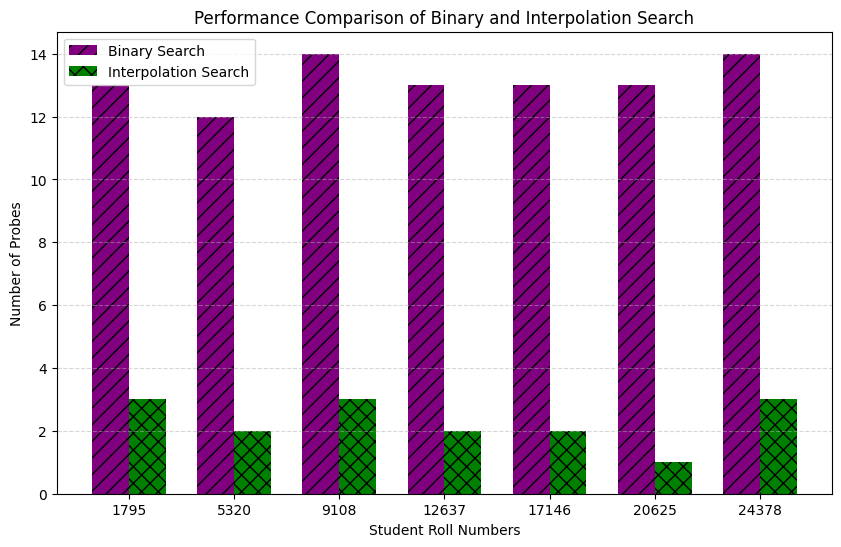

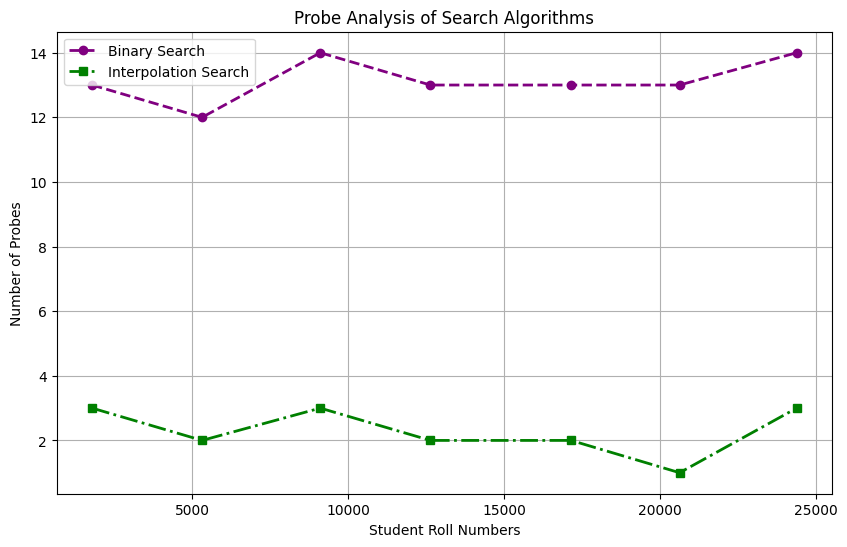

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------
# Generate Non-Uniform Sorted Roll Numbers
# ----------------------------------------
random.seed(10)

roll_numbers = []
value = 0

for i in range(10000):
    value += random.randint(1, 4)
    roll_numbers.append(value)

# ----------------------------------------
# Binary Search
# ----------------------------------------
def binary_search(arr, key):
    left = 0
    right = len(arr) - 1
    probes = 0

    while left <= right:
        probes += 1
        mid = (left + right) // 2

        if arr[mid] == key:
            return probes

        elif arr[mid] < key:
            left = mid + 1

        else:
            right = mid - 1

    return probes


# ----------------------------------------
# Interpolation Search
# ----------------------------------------
def interpolation_search(arr, key):

    low = 0
    high = len(arr) - 1
    probes = 0

    while (low <= high and
           key >= arr[low] and
           key <= arr[high]):

        probes += 1

        if low == high:
            return probes

        pos = low + int(
            ((key - arr[low]) * (high - low))
            / (arr[high] - arr[low])
        )

        if arr[pos] == key:
            return probes

        elif arr[pos] < key:
            low = pos + 1

        else:
            high = pos - 1

    return probes


# ----------------------------------------
# Search Targets
# ----------------------------------------
targets = [
    roll_numbers[700],
    roll_numbers[2100],
    roll_numbers[3600],
    roll_numbers[5000],
    roll_numbers[6800],
    roll_numbers[8200],
    roll_numbers[9700]
]

binary_probes = []
interpolation_probes = []

for target in targets:
    binary_probes.append(
        binary_search(roll_numbers, target)
    )

    interpolation_probes.append(
        interpolation_search(roll_numbers, target)
    )

# ----------------------------------------
# Display Results
# ----------------------------------------
print("\nSEARCH RESULTS")
print("-" * 60)

for i in range(len(targets)):
    print(
        f"Roll No: {targets[i]} | "
        f"Binary Search Probes: {binary_probes[i]} | "
        f"Interpolation Search Probes: {interpolation_probes[i]}"
    )

# ----------------------------------------
# BAR CHART
# ----------------------------------------
x = np.arange(len(targets))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    binary_probes,
    width,
    label="Binary Search",
    color="purple",
    hatch="//"
)

plt.bar(
    x + width/2,
    interpolation_probes,
    width,
    label="Interpolation Search",
    color="green",
    hatch="xx"
)

plt.xticks(x, [str(t) for t in targets])

plt.xlabel("Student Roll Numbers")
plt.ylabel("Number of Probes")
plt.title("Performance Comparison of Binary and Interpolation Search")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# ----------------------------------------
# LINE CHART
# ----------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    targets,
    binary_probes,
    marker='o',
    linestyle='--',
    linewidth=2,
    color='purple',
    label='Binary Search'
)

plt.plot(
    targets,
    interpolation_probes,
    marker='s',
    linestyle='-.',
    linewidth=2,
    color='green',
    label='Interpolation Search'
)

plt.xlabel("Student Roll Numbers")
plt.ylabel("Number of Probes")
plt.title("Probe Analysis of Search Algorithms")
plt.legend()
plt.grid(True)

plt.show()